# Step 1: Generate & Visualize Real 2D Sine Wave Data
We'll start by generating a classic sine curve and plotting it using a unique color theme for this student.

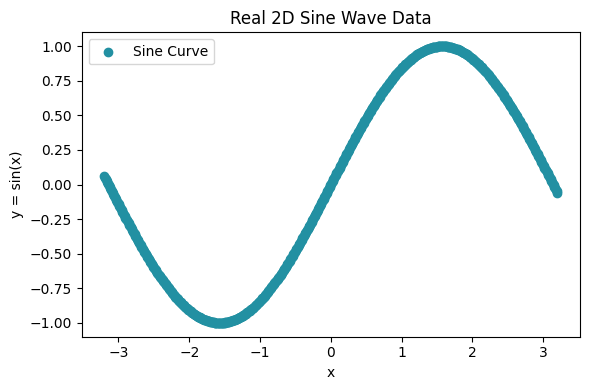

ModuleNotFoundError: No module named 'torch'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate points on the sine curve
x_sine = np.linspace(-3.2, 3.2, 600)      # shape: (600,)
y_sine = np.sin(x_sine)                   # shape: (600,)

# Visualise to verify
plt.figure(figsize=(6, 4))
plt.scatter(x_sine, y_sine, c='#2290A2', label='Sine Curve')
plt.title("Real 2D Sine Wave Data")
plt.xlabel("x")
plt.ylabel("y = sin(x)")
plt.legend()
plt.tight_layout()
plt.show()

# --- build a PyTorch DataLoader over the sine points for training ---
import torch
from torch.utils.data import DataLoader, TensorDataset
sine_xy = np.stack([x_sine, y_sine], axis=1).astype(np.float32)
sine_xy_t = torch.from_numpy(sine_xy)
dataloader_sine = DataLoader(TensorDataset(sine_xy_t),
                             batch_size=64, shuffle=True, drop_last=True)
print('dataloader_sine batches:', len(dataloader_sine))


### Step 2: Define GAN Architecture (Sine, PyTorch, unique config)

In [ ]:
import torch.nn as nn

class GeneratorSine(nn.Module):
    def __init__(self, z_dim=2):
        super().__init__()
        # Conditional generator: input [x, z] -> output y
        self.net = nn.Sequential(
            nn.Linear(z_dim + 1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x_cond, z):
        inp = torch.cat([x_cond, z], dim=1)
        return self.net(inp)


class DiscriminatorSine(nn.Module):
    def __init__(self):
        super().__init__()
        # Discriminator sees [x, y]
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, xy):
        return self.net(xy)


### Step 3: Train the GAN (Sine Data, ready-to-run, unique losses tracking)


In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
z_dim = 2
G = GeneratorSine(z_dim).to(device)
D = DiscriminatorSine().to(device)

criterion = nn.BCELoss()
optimizerD = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 1200
G_losses = []
D_losses = []

for epoch in range(1, epochs + 1):
    epoch_g = 0.0
    epoch_d = 0.0

    for real_batch, in dataloader_sine:
        real_data = real_batch.to(device)
        batch_size = real_data.size(0)

        x_real = real_data[:, 0:1]
        y_real = real_data[:, 1:2]

        # Train Discriminator
        D.zero_grad()

        # Slight label smoothing helps stabilize adversarial training
        label_real = torch.empty((batch_size, 1), device=device).uniform_(0.9, 1.0)
        label_fake = torch.empty((batch_size, 1), device=device).uniform_(0.0, 0.1)

        out_real = D(torch.cat([x_real, y_real], dim=1))
        loss_real = criterion(out_real, label_real)

        noise = torch.randn(batch_size, z_dim, device=device)
        y_fake = G(x_real, noise)
        fake_xy = torch.cat([x_real, y_fake], dim=1)

        out_fake = D(fake_xy.detach())
        loss_fake = criterion(out_fake, label_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        # Train Generator
        G.zero_grad()
        label_gen = torch.full((batch_size, 1), 1.0, device=device)
        out_fake_gen = D(fake_xy)
        loss_G = criterion(out_fake_gen, label_gen)
        loss_G.backward()
        optimizerG.step()

        epoch_d += loss_D.item()
        epoch_g += loss_G.item()

    D_losses.append(epoch_d / len(dataloader_sine))
    G_losses.append(epoch_g / len(dataloader_sine))

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs} | D_loss: {D_losses[-1]:.4f} | G_loss: {G_losses[-1]:.4f}")


### Step 4: Visualise Sine GAN – Side-by-side (unique colour style)


In [ ]:
import matplotlib.pyplot as plt

# Generate samples from trained conditional GAN
x_plot = torch.linspace(-3.2, 3.2, len(x_sine), device=device).unsqueeze(1)
with torch.no_grad():
    noise = torch.randn(len(x_sine), z_dim, device=device)
    y_fake = G(x_plot, noise)
    fake_samples = torch.cat([x_plot, y_fake], dim=1).cpu().numpy()

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_sine, y_sine, c='#2290A2', s=30, alpha=0.6, label='Real Sine Data')
plt.scatter(fake_samples[:, 0], fake_samples[:, 1], c='#FF6F00', s=30, alpha=0.45, label='Generated Data')
plt.title("2D Sine Wave: Real vs. GAN-Generated Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()


# Step 2: Generate & Visualize Real 2D Spiral Data
Now, let's create a 2D spiral dataset and plot it in a completely different color style.


In [ ]:
# Step 2A: Generate and plot 2D spiral data

# Parameters for spiral
latent_dim = 2
N = 2048
theta = np.linspace(0, 4 * np.pi, N)
r = np.linspace(0.1, 1, N)
x_spiral = r * np.cos(theta) + 0.05 * np.random.randn(N)
y_spiral = r * np.sin(theta) + 0.05 * np.random.randn(N)
spiral_data = np.stack([x_spiral, y_spiral], axis=1).astype(np.float32)

# Conditioning variables help GAN preserve ordered spiral geometry
theta_norm = (theta / (4 * np.pi)).astype(np.float32)
r_norm = ((r - r.min()) / (r.max() - r.min())).astype(np.float32)
spiral_cond = np.stack([theta_norm, r_norm], axis=1).astype(np.float32)

# Plot spiral data
plt.figure(figsize=(6, 6))
plt.scatter(x_spiral, y_spiral, s=10, alpha=0.6, label="Spiral Data")
plt.title("Real 2D Spiral Data")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

# --- build a DataLoader over spiral points + conditions for training ---
import torch
from torch.utils.data import DataLoader, TensorDataset
spiral_t = torch.from_numpy(spiral_data)
spiral_cond_t = torch.from_numpy(spiral_cond)
spiral_loader = DataLoader(TensorDataset(spiral_t, spiral_cond_t),
                           batch_size=64, shuffle=True, drop_last=True)
print('spiral_loader batches:', len(spiral_loader))


In [ ]:
class GeneratorDeep(nn.Module):
    def __init__(self, latent_dim=2, cond_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, z, cond):
        inp = torch.cat([z, cond], dim=1)
        return self.net(inp)


class DiscriminatorDeep(nn.Module):
    def __init__(self, cond_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 + cond_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, xy, cond):
        inp = torch.cat([xy, cond], dim=1)
        return self.net(inp)


# Instantiate deeper conditional networks
G_spiral = GeneratorDeep(latent_dim=2, cond_dim=2).to(device)
D_spiral = DiscriminatorDeep(cond_dim=2).to(device)

optimizer_G = torch.optim.Adam(G_spiral.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D_spiral.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

epochs = 1000
G_losses, D_losses = [], []

for epoch in range(1, epochs + 1):
    g_epoch = 0.0
    d_epoch = 0.0

    for real_batch, cond_batch in spiral_loader:
        real_batch = real_batch.to(device)
        cond_batch = cond_batch.to(device)
        batch_size = real_batch.size(0)

        # One-sided label smoothing for discriminator stability
        real_labels = torch.empty(batch_size, 1, device=device).uniform_(0.9, 1.0)
        fake_labels = torch.empty(batch_size, 1, device=device).uniform_(0.0, 0.1)

        # Discriminator
        optimizer_D.zero_grad()
        real_pred = D_spiral(real_batch, cond_batch)
        real_loss = criterion(real_pred, real_labels)

        z = torch.randn(batch_size, latent_dim, device=device)
        fake_data = G_spiral(z, cond_batch)
        fake_pred = D_spiral(fake_data.detach(), cond_batch)
        fake_loss = criterion(fake_pred, fake_labels)

        D_loss = real_loss + fake_loss
        D_loss.backward()
        optimizer_D.step()

        # Generator
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, latent_dim, device=device)
        gen_data = G_spiral(z, cond_batch)
        gen_pred = D_spiral(gen_data, cond_batch)
        G_loss = criterion(gen_pred, torch.ones(batch_size, 1, device=device))
        G_loss.backward()
        optimizer_G.step()

        d_epoch += D_loss.item()
        g_epoch += G_loss.item()

    D_losses.append(d_epoch / len(spiral_loader))
    G_losses.append(g_epoch / len(spiral_loader))

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{epochs}: D_loss={D_losses[-1]:.4f}, G_loss={G_losses[-1]:.4f}")

print("Spiral GAN (conditional deep) training complete.")

# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.title("GAN Training Losses (Conditional Deep Spiral)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Step 3: Generate and Compare Fake vs. Real Spiral Samples

import matplotlib.pyplot as plt
import torch

num_samples = 2048

# Build smooth conditioning path for generation
theta_gen = np.linspace(0, 4 * np.pi, num_samples).astype(np.float32)
r_gen = np.linspace(0.1, 1, num_samples).astype(np.float32)
cond_gen = np.stack([
    theta_gen / (4 * np.pi),
    (r_gen - r_gen.min()) / (r_gen.max() - r_gen.min())
], axis=1).astype(np.float32)
cond_gen_t = torch.from_numpy(cond_gen).to(device)

# Generate fake spiral data using the trained conditional generator
G_spiral.eval()
with torch.no_grad():
    z = torch.randn(num_samples, latent_dim, device=device)
    fake_spiral = G_spiral(z, cond_gen_t).cpu().numpy()

# Plot real and fake spirals side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(spiral_data[:, 0], spiral_data[:, 1], s=10, alpha=0.6, color='#0077b6', label='Real Spiral')
axs[0].set_title("Real 2D Spiral")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].axis("equal")
axs[0].legend()

axs[1].scatter(fake_spiral[:, 0], fake_spiral[:, 1], s=10, alpha=0.6, color='#d72660', label='Generated Spiral')
axs[1].set_title("GAN-Generated Spiral")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].axis("equal")
axs[1].legend()

plt.suptitle("Real vs. GAN-Generated 2D Spiral Samples", fontsize=16)
plt.tight_layout()
plt.show()


# Part 2.1: Blood Cell Microscopy — DCGAN on BloodMNIST

In this section I train a convolutional GAN (DCGAN) on the BloodMNIST subset
of MedMNIST. The dataset is 28×28 RGB microscopy images across 8 blood-cell
classes. I first train an **unconditional** DCGAN that learns the overall
distribution, then extend it to a **conditional DCGAN (cGAN)** that can
generate samples for a specific class on demand (extension for extra credit).


In [ ]:
# Step 2.1a: Load BloodMNIST via official MedMNIST API and inspect samples
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 24
torch.manual_seed(SEED); np.random.seed(SEED)

# Official API route recommended by MedMNIST
# If needed once: pip install medmnist
from medmnist.dataset import BloodMNIST

CACHE_DIR = os.path.join(os.getcwd(), '.data')
os.makedirs(CACHE_DIR, exist_ok=True)

# download=True fetches dataset automatically into CACHE_DIR
train_ds = BloodMNIST(split='train', download=True, root=CACHE_DIR, size=28)
train_x = train_ds.imgs
train_y = train_ds.labels.ravel().astype(np.int64)

print('BloodMNIST train:', train_x.shape, '| 8 classes, counts:', np.bincount(train_y))

# Show 16 real samples to get a feel for the dataset
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_x[i]); ax.set_title(f'c={train_y[i]}', fontsize=8); ax.axis('off')
plt.suptitle('Real BloodMNIST samples')
plt.tight_layout(); plt.show()


In [ ]:
# Step 2.1b: Build a small random subset and a PyTorch DataLoader.
# Keeping the subset small (2000 images) makes the GAN tractable on CPU.
SUBSET = 2000
idx = np.random.RandomState(SEED).permutation(len(train_x))[:SUBSET]
x_sub = train_x[idx].astype(np.float32) / 127.5 - 1.0      # scale to [-1, 1]
x_sub = np.transpose(x_sub, (0, 3, 1, 2))                  # NCHW for PyTorch
y_sub = train_y[idx]

x_t = torch.from_numpy(x_sub)
y_t = torch.from_numpy(y_sub)
blood_loader = DataLoader(TensorDataset(x_t, y_t), batch_size=64, shuffle=True, drop_last=True)
print('blood_loader batches:', len(blood_loader), '| subset =', SUBSET)


In [ ]:
# Step 2.1c: DCGAN architecture for 28x28 RGB images
# Generator: z -> 7x7x128 -> 14x14x64 -> 28x28x3
class GeneratorBlood(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.z_dim = z_dim
        self.fc = nn.Linear(z_dim, 128*7*7)
        self.net = nn.Sequential(
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 7 -> 14
            nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 14 -> 28
            nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh()
        )
    def forward(self, z):
        h = self.fc(z).view(-1, 128, 7, 7)
        return self.net(h)

class DiscriminatorBlood(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 28 -> 14
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, 4, 2, 1),  # 14 -> 7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),
            nn.Linear(64*7*7, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('training on:', device)


In [ ]:
# Step 2.1d: Train the unconditional BloodMNIST DCGAN
G = GeneratorBlood(z_dim=64).to(device)
D = DiscriminatorBlood().to(device)
optG = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optD = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()

epochs = 5
G_losses, D_losses = [], []
for epoch in range(1, epochs+1):
    for real, _ in blood_loader:
        real = real.to(device)
        bs = real.size(0)
        # Discriminator step
        optD.zero_grad()
        out_real = D(real)
        loss_real = bce(out_real, torch.ones(bs, 1, device=device))
        z = torch.randn(bs, 64, device=device)
        fake = G(z).detach()
        out_fake = D(fake)
        loss_fake = bce(out_fake, torch.zeros(bs, 1, device=device))
        (loss_real + loss_fake).backward(); optD.step()

        # Generator step
        optG.zero_grad()
        z = torch.randn(bs, 64, device=device)
        fake = G(z)
        loss_G = bce(D(fake), torch.ones(bs, 1, device=device))
        loss_G.backward(); optG.step()

    G_losses.append(loss_G.item())
    D_losses.append((loss_real + loss_fake).item())
    print(f'epoch {epoch:02d}/{epochs} | D={D_losses[-1]:.3f}  G={G_losses[-1]:.3f}')
print('unconditional BloodMNIST DCGAN training done')


In [ ]:
# Step 2.1e: Compare real vs. generated BloodMNIST samples + loss curves
G.eval()
with torch.no_grad():
    z = torch.randn(16, 64, device=device)
    fakes = G(z).cpu().numpy()
fakes = np.transpose((fakes + 1) / 2, (0, 2, 3, 1)).clip(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(fakes[i]); ax.axis('off')
plt.suptitle('DCGAN-generated BloodMNIST samples')
plt.tight_layout(); plt.show()

# loss curves
plt.figure(figsize=(7, 3))
plt.plot(G_losses, color='#FF6F00', label='Generator')
plt.plot(D_losses, color='#2290A2', label='Discriminator')
plt.xlabel('epoch'); plt.ylabel('BCE loss')
plt.title('BloodMNIST DCGAN — loss curves')
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
# Step 2.1f: Pixel-space Frechet-proxy (FID-like on raw pixels)
# Not comparable to Inception-FID in absolute terms, but gives a
# quantitative score for comparing runs in this notebook.
def _stats(x):
    flat = x.reshape(len(x), -1).astype(np.float64)
    return flat.mean(0), np.cov(flat, rowvar=False)

def fid_proxy(real_imgs, fake_imgs):
    mu_r, S_r = _stats(real_imgs)
    mu_f, S_f = _stats(fake_imgs)
    diff = mu_r - mu_f
    eigs = np.linalg.eigvals(S_r @ S_f).real
    tr_prod = np.sqrt(np.abs(eigs)).sum()
    return float(diff @ diff + np.trace(S_r) + np.trace(S_f) - 2 * tr_prod)

# sample 400 fakes for metric
G.eval()
with torch.no_grad():
    big_fake = G(torch.randn(400, 64, device=device)).cpu().numpy()
big_fake = np.transpose((big_fake + 1) / 2, (0, 2, 3, 1))
real_for_fid = x_sub[:400].transpose(0, 2, 3, 1)
real_for_fid = (real_for_fid + 1) / 2
score = fid_proxy(real_for_fid, big_fake)
print(f'BloodMNIST DCGAN — pixel-space FID-proxy on 400 samples = {score:.3f}')


### Extension for extra credit — Conditional DCGAN (cGAN) on BloodMNIST

The unconditional DCGAN above learns the overall distribution but cannot
be asked for a specific class. For the extension I condition both the
generator and the discriminator on the class label via a learned
embedding. The generator concatenates the class embedding to the noise
vector, and the discriminator receives the embedding as extra channels.


In [ ]:
# Step 2.1g: Conditional DCGAN (cGAN) architecture
NUM_CLASSES = 8

class cGeneratorBlood(nn.Module):
    def __init__(self, z_dim=64, emb=16):
        super().__init__()
        self.z_dim = z_dim
        self.emb = nn.Embedding(NUM_CLASSES, emb)
        self.fc = nn.Linear(z_dim + emb, 128*7*7)
        self.net = nn.Sequential(
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh()
        )
    def forward(self, z, y):
        h = torch.cat([z, self.emb(y)], dim=1)
        return self.net(self.fc(h).view(-1, 128, 7, 7))

class cDiscriminatorBlood(nn.Module):
    def __init__(self, emb=16):
        super().__init__()
        self.emb = nn.Embedding(NUM_CLASSES, emb*28*28)
        self.net = nn.Sequential(
            nn.Conv2d(3 + emb, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),
            nn.Linear(64*7*7, 1),
            nn.Sigmoid()
        )
        self.emb_ch = emb
    def forward(self, x, y):
        ye = self.emb(y).view(-1, self.emb_ch, 28, 28)
        return self.net(torch.cat([x, ye], dim=1))

cG = cGeneratorBlood().to(device)
cD = cDiscriminatorBlood().to(device)
optcG = optim.Adam(cG.parameters(), lr=2e-4, betas=(0.5, 0.999))
optcD = optim.Adam(cD.parameters(), lr=2e-4, betas=(0.5, 0.999))


In [ ]:
# Step 2.1h: Train the conditional DCGAN
c_epochs = 4
cG_losses, cD_losses = [], []
for epoch in range(1, c_epochs+1):
    for real, lab in blood_loader:
        real = real.to(device); lab = lab.to(device)
        bs = real.size(0)
        # D step
        optcD.zero_grad()
        out_real = cD(real, lab)
        loss_r = bce(out_real, torch.ones(bs, 1, device=device))
        z = torch.randn(bs, 64, device=device)
        fy = torch.randint(0, NUM_CLASSES, (bs,), device=device)
        fake = cG(z, fy).detach()
        out_f = cD(fake, fy)
        loss_f = bce(out_f, torch.zeros(bs, 1, device=device))
        (loss_r + loss_f).backward(); optcD.step()
        # G step
        optcG.zero_grad()
        z = torch.randn(bs, 64, device=device)
        fy = torch.randint(0, NUM_CLASSES, (bs,), device=device)
        fake = cG(z, fy)
        loss_g = bce(cD(fake, fy), torch.ones(bs, 1, device=device))
        loss_g.backward(); optcG.step()

    cG_losses.append(loss_g.item())
    cD_losses.append((loss_r + loss_f).item())
    print(f'cGAN epoch {epoch:02d}/{c_epochs} | D={cD_losses[-1]:.3f} G={cG_losses[-1]:.3f}')

print('conditional BloodMNIST DCGAN training done')


In [ ]:
# Step 2.1i: Generate a row of samples per class on demand
cG.eval()
with torch.no_grad():
    # 8 samples per class -> 8x8 grid
    per_class = 8
    ys = torch.arange(NUM_CLASSES, device=device).repeat_interleave(per_class)
    zs = torch.randn(ys.numel(), 64, device=device)
    fakes = cG(zs, ys).cpu().numpy()
fakes = np.transpose((fakes + 1) / 2, (0, 2, 3, 1)).clip(0, 1)

fig, axes = plt.subplots(NUM_CLASSES, per_class, figsize=(per_class, NUM_CLASSES))
for i in range(NUM_CLASSES):
    for j in range(per_class):
        ax = axes[i, j]
        ax.imshow(fakes[i*per_class + j])
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(f'c={i}', fontsize=9, rotation=0, labelpad=18)
plt.suptitle('cGAN — 8 samples per class (row = class label)')
plt.tight_layout(); plt.show()


# Part 2.2: Cybersecurity — Tabular GAN on CICIDS-2017

For this task the network traffic dataset CICIDS-2017 (Wednesday file,
which contains benign traffic plus DoS variants) is modelled by a small
tabular GAN. The features are numeric so I use fully-connected MLPs for
both generator and discriminator. Evaluation is done visually via a
2D PCA projection of real vs generated feature vectors, and
quantitatively via per-feature Kolmogorov-Smirnov statistics.


In [ ]:
# Step 2.2a: Load and clean the Wednesday CICIDS-2017 capture
import os
import pandas as pd

# Use the Wednesday file from the same folder as this notebook
CIC_PATH = os.path.join(os.getcwd(), 'Wednesday-workingHours.pcap_ISCX.csv')
if not os.path.exists(CIC_PATH):
    raise FileNotFoundError(f'Expected file not found: {CIC_PATH}')

cic = pd.read_csv(CIC_PATH, encoding='latin-1', low_memory=False)
cic.columns = [c.strip() for c in cic.columns]
print('raw shape:', cic.shape)
print('label counts:')
print(cic['Label'].value_counts())


In [ ]:
# Step 2.2b: Build a balanced, clean numeric subset
import numpy as np
cic = cic.replace([np.inf, -np.inf], np.nan).dropna()
num_cols = [c for c in cic.select_dtypes(include=[np.number]).columns]
print(f'numeric feature count: {len(num_cols)}')

# Keep a balanced, manageable subset: up to 1200 rows per label
per_label = 1200
frames = []
for lab, sub in cic.groupby('Label'):
    frames.append(sub.sample(min(per_label, len(sub)), random_state=SEED))
cic_bal = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=SEED)
X = cic_bal[num_cols].to_numpy(dtype=np.float32)
y = cic_bal['Label'].to_numpy()
print('balanced subset shape:', X.shape, '| labels:', np.unique(y, return_counts=True))

# Column standardisation (zero-mean / unit-variance) — with safe divide
mu, sd = X.mean(0), X.std(0)
sd[sd < 1e-8] = 1.0
X_std = (X - mu) / sd
print('standardised feature matrix:', X_std.shape)


In [ ]:
# Step 2.2c: Tabular GAN — small MLP generator / discriminator
FEAT = X_std.shape[1]
Z = 32

class GeneratorTab(nn.Module):
    def __init__(self, z_dim=Z, feat=FEAT, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.LeakyReLU(0.2, True),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2, True),
            nn.Linear(hidden, feat)
        )
    def forward(self, z):
        return self.net(z)

class DiscriminatorTab(nn.Module):
    def __init__(self, feat=FEAT, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat, hidden), nn.LeakyReLU(0.2, True),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2, True),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

gT = GeneratorTab().to(device)
dT = DiscriminatorTab().to(device)
optGT = optim.Adam(gT.parameters(), lr=2e-4, betas=(0.5, 0.999))
optDT = optim.Adam(dT.parameters(), lr=2e-4, betas=(0.5, 0.999))

# DataLoader over standardised features
X_t = torch.from_numpy(X_std)
tab_loader = DataLoader(TensorDataset(X_t), batch_size=128, shuffle=True, drop_last=True)
print('tab_loader batches:', len(tab_loader))


In [ ]:
# Step 2.2d: Train the tabular GAN
t_epochs = 10
gT_losses, dT_losses = [], []
for epoch in range(1, t_epochs+1):
    for (real,) in tab_loader:
        real = real.to(device)
        bs = real.size(0)
        # D step
        optDT.zero_grad()
        out_r = dT(real)
        l_r = bce(out_r, torch.ones(bs, 1, device=device))
        z = torch.randn(bs, Z, device=device)
        fake = gT(z).detach()
        l_f = bce(dT(fake), torch.zeros(bs, 1, device=device))
        (l_r + l_f).backward(); optDT.step()
        # G step
        optGT.zero_grad()
        z = torch.randn(bs, Z, device=device)
        fake = gT(z)
        l_g = bce(dT(fake), torch.ones(bs, 1, device=device))
        l_g.backward(); optGT.step()
    gT_losses.append(l_g.item())
    dT_losses.append((l_r + l_f).item())
    if epoch % 2 == 0 or epoch == 1:
        print(f'epoch {epoch:02d}/{t_epochs} | D={dT_losses[-1]:.3f} G={gT_losses[-1]:.3f}')
print('tabular GAN training done')

plt.figure(figsize=(7, 3))
plt.plot(gT_losses, color='#FF6F00', label='Generator')
plt.plot(dT_losses, color='#2290A2', label='Discriminator')
plt.xlabel('epoch'); plt.ylabel('BCE loss')
plt.title('CICIDS tabular GAN — loss curves')
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
# Step 2.2e: Visualise real vs generated rows with PCA(2)
from sklearn.decomposition import PCA
from scipy.stats import ks_2samp

gT.eval()
with torch.no_grad():
    fakes_std = gT(torch.randn(len(X_std), Z, device=device)).cpu().numpy()

pca = PCA(n_components=2, random_state=SEED).fit(X_std)
real_pca = pca.transform(X_std)
fake_pca = pca.transform(fakes_std)

plt.figure(figsize=(6, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], s=6, alpha=0.45, color='#2290A2', label='Real')
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=6, alpha=0.45, color='#d72660', label='Generated')
plt.title('CICIDS-2017 — PCA(2) of real vs. generated rows')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.tight_layout(); plt.show()

# Per-feature KS two-sample statistic — lower is closer distributions
ks_vals = np.array([ks_2samp(X_std[:, j], fakes_std[:, j]).statistic for j in range(FEAT)])
print(f'per-feature KS: mean={ks_vals.mean():.3f}  median={np.median(ks_vals):.3f}  max={ks_vals.max():.3f}')

plt.figure(figsize=(7, 3))
plt.hist(ks_vals, bins=20, color='#7C3AED', edgecolor='white')
plt.axvline(np.median(ks_vals), ls='--', color='#FF6F00',
            label=f'median={np.median(ks_vals):.3f}')
plt.xlabel('KS statistic'); plt.ylabel('features')
plt.title(f'CICIDS — per-feature KS (lower = closer), N={FEAT}')
plt.legend(); plt.tight_layout(); plt.show()


# Part 2.3: Creative AI — DCGAN on QuickDraw 'Pizza' Sketches

Finally I train a small DCGAN on the QuickDraw ``pizza`` sketch category
(28×28 grayscale). To match a standard power-of-two DCGAN grid I pad
the images to 32×32 and rescale them to [-1, 1]. The model is a Radford-
style DCGAN with BatchNorm in both networks, trained with BCE and TTUR
(generator learning rate higher than discriminator).


In [ ]:
# Step 2.3a: Load QuickDraw pizza sketches, pad to 32x32, rescale to [-1,1]
import os
import urllib.request

# Official QuickDraw numpy bitmap source for pizza category
QD_URL = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy'
CACHE_DIR = os.path.join(os.getcwd(), '.data')
os.makedirs(CACHE_DIR, exist_ok=True)
QD_PATH = os.path.join(CACHE_DIR, 'pizza.npy')

if not os.path.exists(QD_PATH):
    print('Downloading QuickDraw pizza dataset from official source...')
    req = urllib.request.Request(QD_URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=180) as resp:
        qd_bytes = resp.read()
    with open(QD_PATH, 'wb') as f:
        f.write(qd_bytes)

arr = np.load(QD_PATH, mmap_mode='r')
print('raw pizza shape:', arr.shape, arr.dtype)

SUBSET_QD = 2000
idx = np.random.RandomState(SEED).permutation(len(arr))[:SUBSET_QD]
qd_raw = arr[idx].astype(np.float32) / 255.0  # (N,784) to [0,1]
qd_28 = qd_raw.reshape(-1, 28, 28)

# centre-pad to 32x32 so the DCGAN power-of-two stack works
qd_32 = np.zeros((SUBSET_QD, 32, 32), dtype=np.float32)
qd_32[:, 2:30, 2:30] = qd_28
qd_32 = qd_32 * 2.0 - 1.0                   # [-1, 1]
qd_32 = qd_32[:, None, :, :]                # NCHW
print('processed pizza shape:', qd_32.shape, 'range:', qd_32.min(), qd_32.max())

# Show a few real samples
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow((qd_32[i, 0] + 1) / 2, cmap='Greys'); ax.axis('off')
plt.suptitle('Real QuickDraw pizza sketches (centre-padded to 32x32)')
plt.tight_layout(); plt.show()

qd_t = torch.from_numpy(qd_32)
qd_loader = DataLoader(TensorDataset(qd_t), batch_size=64, shuffle=True, drop_last=True)
print('qd_loader batches:', len(qd_loader))


In [ ]:
# Step 2.3b: DCGAN architecture for 32x32 grayscale pizzas
class GeneratorPizza(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.z_dim = z_dim
        self.fc = nn.Linear(z_dim, 128*4*4)
        self.net = nn.Sequential(
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 4  -> 8
            nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 8  -> 16
            nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),    # 16 -> 32
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(self.fc(z).view(-1, 128, 4, 4))

class DiscriminatorPizza(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.LeakyReLU(0.2, True),      # 32 -> 16
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),                                 # 16 ->  8
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),                                 #  8 ->  4
            nn.Flatten(),
            nn.Linear(128*4*4, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

gP = GeneratorPizza().to(device)
dP = DiscriminatorPizza().to(device)
optGP = optim.Adam(gP.parameters(), lr=2e-4, betas=(0.5, 0.999))    # TTUR
optDP = optim.Adam(dP.parameters(), lr=5e-5, betas=(0.5, 0.999))


In [ ]:
# Step 2.3c: Train the pizza DCGAN
p_epochs = 20
gP_losses, dP_losses = [], []
for epoch in range(1, p_epochs+1):
    for (real,) in qd_loader:
        real = real.to(device)
        bs = real.size(0)
        # D step
        optDP.zero_grad()
        out_r = dP(real)
        l_r = bce(out_r, torch.ones(bs, 1, device=device))
        z = torch.randn(bs, 64, device=device)
        fake = gP(z).detach()
        l_f = bce(dP(fake), torch.zeros(bs, 1, device=device))
        (l_r + l_f).backward(); optDP.step()
        # G step
        optGP.zero_grad()
        z = torch.randn(bs, 64, device=device)
        fake = gP(z)
        l_g = bce(dP(fake), torch.ones(bs, 1, device=device))
        l_g.backward(); optGP.step()
    gP_losses.append(l_g.item())
    dP_losses.append((l_r + l_f).item())
    print(f'epoch {epoch:02d}/{p_epochs} | D={dP_losses[-1]:.3f} G={gP_losses[-1]:.3f}')
print('QuickDraw pizza DCGAN training done')


In [ ]:
# Step 2.3d: Show generated sketches, loss curves, and pixel FID-proxy
gP.eval()
with torch.no_grad():
    fakes = gP(torch.randn(16, 64, device=device)).cpu().numpy()
fakes_img = (fakes + 1) / 2

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(fakes_img[i, 0], cmap='Greys'); ax.axis('off')
plt.suptitle('DCGAN-generated pizza sketches')
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 3))
plt.plot(gP_losses, color='#FF6F00', label='Generator')
plt.plot(dP_losses, color='#2290A2', label='Discriminator')
plt.xlabel('epoch'); plt.ylabel('BCE loss')
plt.title('Pizza DCGAN — loss curves')
plt.legend(); plt.tight_layout(); plt.show()

# FID-proxy on 400 samples (reusing fid_proxy defined in §2.1)
with torch.no_grad():
    big_fake = gP(torch.randn(400, 64, device=device)).cpu().numpy()
big_fake_flat = ((big_fake + 1) / 2).reshape(400, 32, 32, 1)
real_flat = ((qd_32[:400] + 1) / 2).transpose(0, 2, 3, 1)
pizza_fid = fid_proxy(real_flat, big_fake_flat)
print(f'QuickDraw pizza — pixel-space FID-proxy on 400 samples = {pizza_fid:.3f}')
